In [1]:
# import key libraries and kernel settings
import os
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols, mixedlm
import time
from datetime import date
import matplotlib.lines as mlines

# updated src file changes are loaded
%load_ext autoreload
%autoreload 2

sys.path.append(os.path.abspath(".."))

In [5]:
# first we need to loop through each target x water speed csv and convert them from wide to long format.
def load_solutions_convert_to_long_format(
                                  file_path_list=["C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_L60.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_L30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_R30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-2_R60.csv",
                                                  
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_L60.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_L30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_R30.csv",
                                                  "C:/Users/jacob/water_current_MA/data/solution_space/errors_-3_R60.csv"]):
    # initialize df
    combined_df = pd.DataFrame()

    for file in file_path_list:

        # extract current water speed vals
        current_speed = int(file[-10:-8])
        current_target = file[-7:-4]
        
        # read csv per file loop
        df_wide = pd.read_csv(file)

        # change name of df_tmp 'unnamed' column
        df_wide.rename(columns={'Unnamed: 0': 'speed'}, inplace=True)

        # convert to long format
        df_long = df_wide.melt(
            id_vars=['speed'],
            var_name = 'angle',
            value_name = 'error_m'
        )

        # make new column called error_cm
        df_long['error_cm'] = df_long['error_m'] * 100

        # add new columns for current speed & target
        df_long['water_speed'] = current_speed
        df_long['target_id'] = current_target

        # ensure launch angle is a float
        df_long['angle'] = pd.to_numeric(df_long['angle'])
        
        # make boolean variable that labels which launch parameter combinations result in errors below 8.75 cm (based on ball of r = 5.0 cm and target of r = 3.75 cm)
        df_long['is_hit'] = df_long['error_cm'] < 8.75
        
        # make df with ONLY hits since we are comparing the participant's executed launches to the NEAREST valid launch solutions
        df_hits = df_long[df_long['is_hit'] == True].copy()

        # append df_long to a combined df
        combined_df = pd.concat([combined_df, df_hits], ignore_index=True)

    return combined_df
        

In [11]:
solutions_df = load_solutions_convert_to_long_format()
solutions_df

,speed,angle,error_m,error_cm,water_speed,target_id,is_hit
0,7.65,11.0,0.086649,8.664939,-2,L60,True
1,7.70,11.0,0.082720,8.271994,-2,L60,True
2,6.95,11.5,0.083945,8.394546,-2,L60,True
3,7.00,11.5,0.079482,7.948160,-2,L60,True
4,7.05,11.5,0.076267,7.626703,-2,L60,True
...,...,...,...,...,...,...,...
19813,7.90,64.5,0.073845,7.384503,-3,R60,True
19814,7.95,64.5,0.072870,7.286959,-3,R60,True
19815,8.00,64.5,0.069388,6.938780,-3,R60,True
19816,7.95,65.0,0.084747,8.474675,-3,R60,True


In [13]:
# make function to run and extract mahalanobis-like distance from nearest launch solution in manifold

def load_raw_data_extract_sd_vectors(load_csv="C:/Users/jacob/water_current_MA/data/solution_space/df_dual_raw.csv",
                                     phases_to_keep=['training_1','training_2']):

    # load file
    df = pd.read_csv(load_csv)[['ppid_full','trial_num','phase','target_x_label','speed_label','set_order','launch_Speed','launch_angle']]

    # filter df so it ONLY contains phases_to_keep
    df_phases = df[df['phase'].isin(phases_to_keep)].copy()

    # extract current water speeds and targets
    water_speeds_str = np.unique(df_phases['speed_label'])
    water_speeds = water_speeds_str.astype(int)
    targets = np.unique(df_phases['target_x_label'])

    # initialize dictionary to store vectors
    launch_vectors = {}
    
    for target in targets:
        for water_speed in water_speeds:
            for phase in phases_to_keep:
    
                # print("TARGET = ", target)
                # print("WATER SPEED =", water_speed)
                
                # filter df so it only contains current target & water speed & phase
                df_filtered = df_phases[(df_phases['target_x_label'] == target) & (df_phases['speed_label'] == water_speed) & (df_phases['phase'] == phase)]
                
                if not df_filtered.empty:  # Ensure the dataframe is not empty
                    
                    # extract ppid, set_order, and trial number vector
                    ppid =  df_filtered['ppid_full'].values
                    trial_num = df_filtered['trial_num'].values
                    set_order = df_filtered['set_order'].values
                    
                    # extract launch speed & angle vector
                    raw_launch_speeds = df_filtered['launch_Speed'].values
                    raw_launch_angles = df_filtered['launch_angle'].values
        
                    # initialize tuple key and store in dictionary
                    key = (target, water_speed, phase)
                    if key not in launch_vectors:
                        launch_vectors[key] = {}
        
                        # add vector of launch speeds & angles per key to dictionary
                        launch_vectors[key]['launch_speeds'] = raw_launch_speeds
                        launch_vectors[key]['launch_angles'] = raw_launch_angles
    
                        # add vector of ppid, set order & trial num to dictionary
                        launch_vectors[key]['ppid_full'] = ppid
                        launch_vectors[key]['trial_num'] = trial_num
                        launch_vectors[key]['set_order'] = set_order
                            
                        speed_std = df_filtered[df_filtered['phase'] == phase]['launch_Speed'].std()
                        launch_vectors[key]['speed_std'] = speed_std
                        
                        angle_std = df_filtered[df_filtered['phase'] == phase]['launch_angle'].std()
                        launch_vectors[key]['angle_std'] = angle_std


    # returns dictionary
    return launch_vectors 
            

In [73]:
def run_mahalanobis_like(raw_dictionary, solution_df):

    # input solution / hit parameter vectors
    result = []

    # grab raw data dictionaries
    for key, value in raw_dictionary.items():
        
        target = key[0]
        water_speed = key[1]
        phase = key[2]

        print(water_speed, target, phase)

        speeds_std = value['speed_std']
        angles_std = value['angle_std']
        
        real_speeds = value['launch_speeds']
        real_angles = value['launch_angles']

        ppid = value['ppid_full']
        trial = value['trial_num']

        solutions_filtered = solution_df[(solution_df['target_id'] == target) & (solution_df['water_speed'] == water_speed)]

        # broadcast and find differences, then normalize by variability of each parameter
        speed_diffs = (real_speeds[:, np.newaxis] - solutions_filtered['speed'].values[np.newaxis, :]) / speeds_std
        angle_diffs = (real_angles[:, np.newaxis] - solutions_filtered['angle'].values[np.newaxis, :]) / angles_std

        # calculate distance from solutions, and extract min distance
        d = np.sqrt((speed_diffs**2) + (angle_diffs**2))
        min_d = np.min(d, axis=1)
        
        print("length of min_d:", len(min_d))

        for i in range(len(min_d)):
            result.append([ppid[i], target, water_speed, phase, trial[i], real_angles[i], real_speeds[i], min_d[i]])

    # Create a DataFrame from the collected data
    columns = ['ppid_full', 'target_id', 'water_speed', 'phase', 'trial_num', 'launch_angle', 'launch_speed', 'min_mahalanobis_distance']
    result_df = pd.DataFrame(result, columns=columns)

    # ensure target order is from Left to Right
    target_orders = ['L60','L30','R30','R60']
    cat_type = pd.CategoricalDtype(categories=target_orders, ordered=True)
    result_df['target_id'] = result_df['target_id'].astype(cat_type)

    result_df = result_df.sort_values(by='target_id').reset_index(drop=True)
    
    return result_df
    
    
    

# Dual Target Training

### All Trials

-3 L30 training_1
length of min_d: 1839
-3 L30 training_2
length of min_d: 1497
-2 L30 training_1
length of min_d: 1643
-2 L30 training_2
length of min_d: 1566
-3 L60 training_1
length of min_d: 1485
-3 L60 training_2
length of min_d: 1865
-2 L60 training_1
length of min_d: 1562
-2 L60 training_2
length of min_d: 1637
-3 R30 training_1
length of min_d: 1407
-3 R30 training_2
length of min_d: 1861
-2 R30 training_1
length of min_d: 1560
-2 R30 training_2
length of min_d: 1642
-3 R60 training_1
length of min_d: 1796
-3 R60 training_2
length of min_d: 1487
-2 R60 training_1
length of min_d: 1631
-2 R60 training_2
length of min_d: 1572
hit min None
hit max None


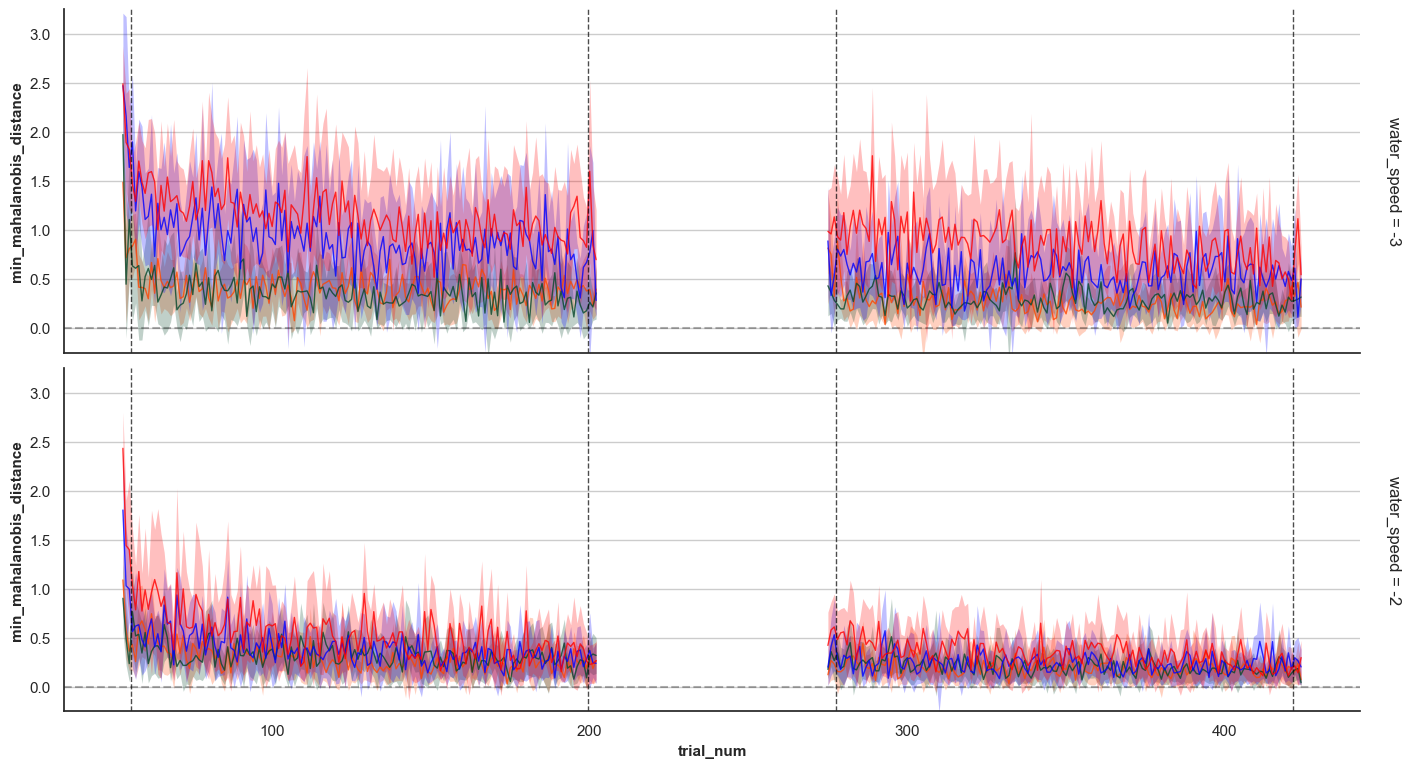

In [75]:
df_dual = load_raw_data_extract_sd_vectors()
df_dual

df_dual_mahalanobis = run_mahalanobis_like(df_dual, solutions_df)


from src.plotting import plot_all_trials

plot_all_trials(df_dual_mahalanobis, 
                     col_col =None,
                     row_col='water_speed',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_id',
                     y_col = 'min_mahalanobis_distance', # 
                     x_col='trial_num',
                     vertical_list=[55.5,199.5, 277.5,421.5],
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col=None,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-0.25,3.25),
                     show_zero_line=True
                    )                    



### Early vs Late Two Trials

In [77]:
df_dual_mahalanobis

,ppid_full,target_id,water_speed,phase,trial_num,launch_angle,launch_speed,min_mahalanobis_distance
0,p051_neg2,L60,-2,training_2,286,35.36956,1.628136,0.329208
1,p023_neg3,L60,-3,training_2,312,38.40723,3.377854,0.240052
2,p023_neg3,L60,-3,training_2,313,26.10285,3.217326,0.177397
3,p023_neg3,L60,-3,training_2,315,29.78950,3.389791,0.018797
4,p023_neg3,L60,-3,training_2,317,27.60415,3.807930,0.012913
...,...,...,...,...,...,...,...,...
26045,p010_neg3,R60,-3,training_2,395,54.59888,3.179992,1.532711
26046,p010_neg3,R60,-3,training_2,393,48.15418,3.463718,0.903712
26047,p010_neg3,R60,-3,training_2,392,49.72755,3.097415,1.401937
26048,p010_neg3,R60,-3,training_2,411,46.42775,3.032321,1.360030


C:\Users\jacob\water_current_MA\src\early_late_exposure.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp = df.groupby(group_cols + [phase_col])


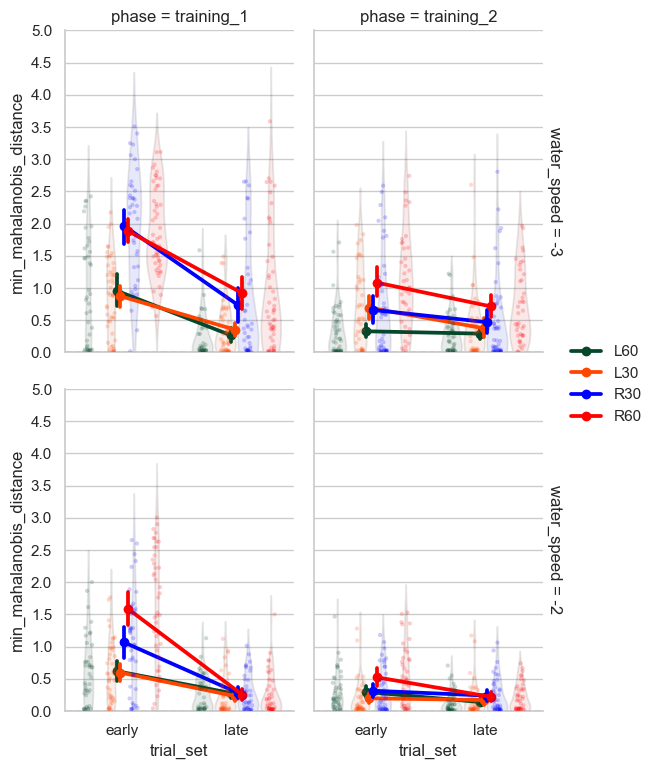

In [101]:
# run function to extract early and late means and make df

from src.early_late_exposure import early_late_phase_new

early_late_dual_df_2 = early_late_phase_new(df = df_dual_mahalanobis,
                 group_cols = ['ppid_full','target_id','water_speed'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'trial_num',
                 n_trials = 2
                ).copy()



from src.plotting import plot_slopes
plot_slopes(early_late_dual_df_2,
                         x_col='trial_set',
                         y_col='min_mahalanobis_distance',
                         hue_var='target_id', 
                         facet_col='phase',
                         facet_row= 'water_speed',
                         y_lim=[0.0, 4.5],
                         y_tick_step=0.5,
                         hit_bounds=None
                            )



# Single Target Training

### All Trials

-3 L60 training_1
length of min_d: 3534
-3 L60 training_2
length of min_d: 1265
-3 R60 training_1
length of min_d: 4283
-3 R60 training_2
length of min_d: 1005
hit min None
hit max None


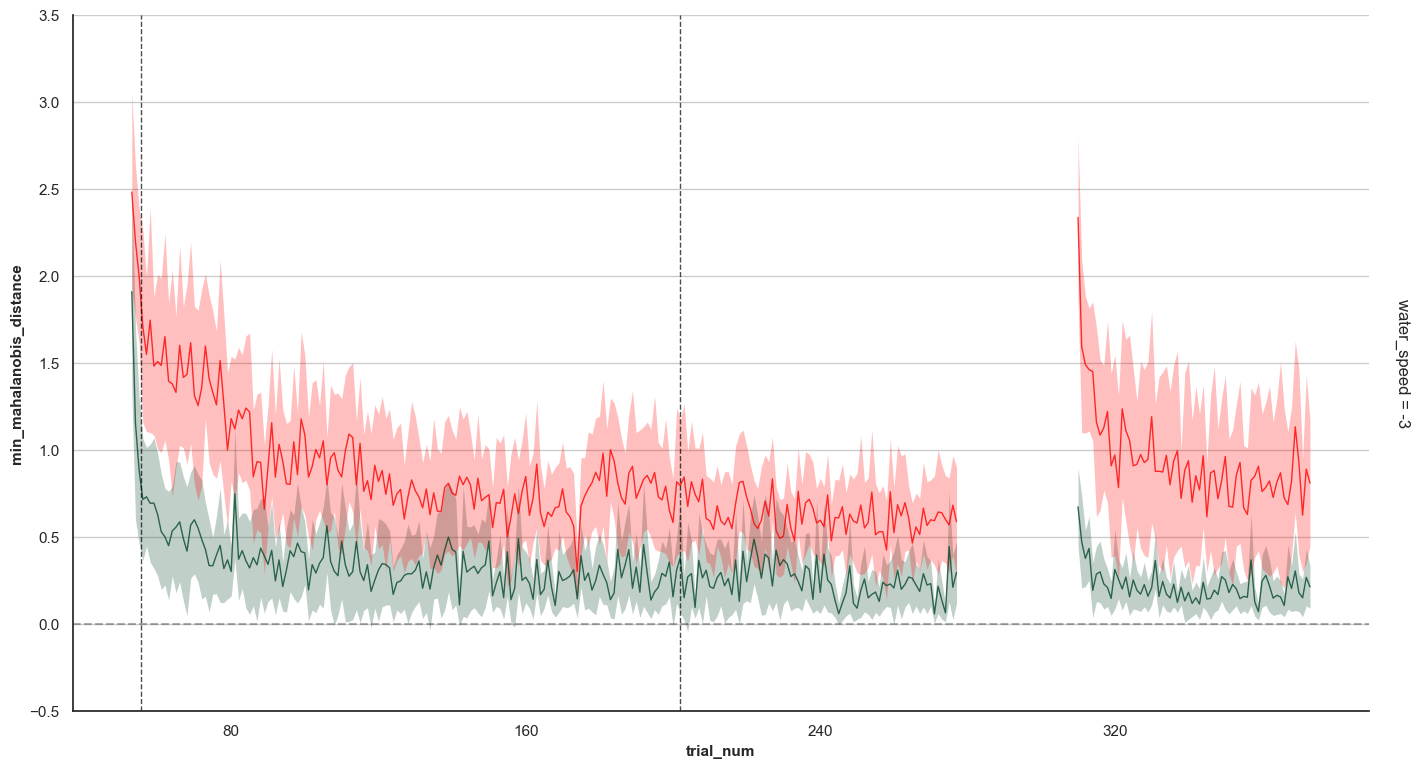

In [19]:


df_single = load_raw_data_extract_sd_vectors(load_csv="C:/Users/jacob/water_current_MA/data/solution_space/df_single_raw.csv")


df_single_mahalanobis = run_mahalanobis_like(df_single, solutions_df)


from src.plotting import plot_all_trials

plot_all_trials(df_single_mahalanobis, 
                     col_col =None,
                     row_col='water_speed',
                     cond_col=None,
                     ppid_col='ppid_full',
                     target_col='target_id',
                     y_col = 'min_mahalanobis_distance', # 
                     x_col='trial_num',
                     vertical_list=[55.5, 202],
                     hit_col='target_hit',
                     ref_range_col=None,
                     no_connect_col='phase',
                     context='notebook', 
                     transition_col=None,
                     marker_size=0,
                     estimator='mean',
                     y_lim=(-0.5,3.5),
                     show_zero_line=True
                    )                    

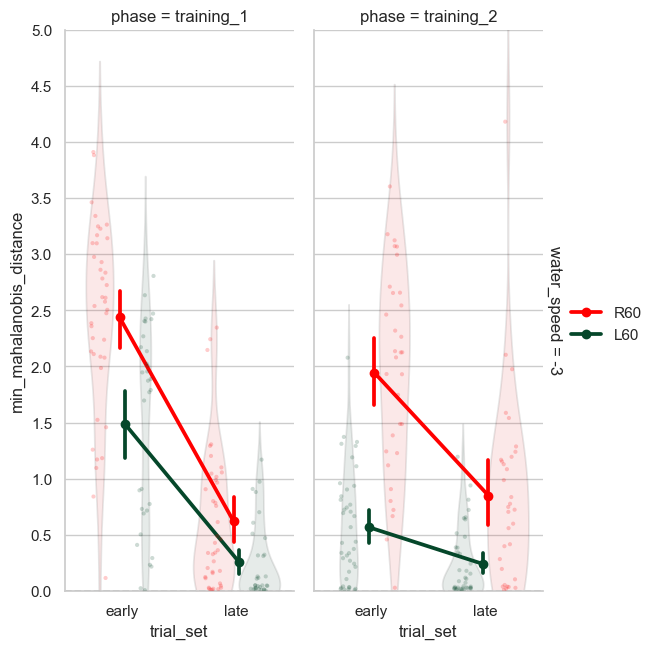

In [97]:
# run function to extract early and late means and make df

from src.early_late_exposure import early_late_phase_new

early_late_single_df_2 = early_late_phase_new(df = df_single_mahalanobis,
                 group_cols = ['ppid_full','target_id','water_speed'],
                 phase_col = 'phase',
                 phases_to_keep=['training_1','training_2'],
                 trial_col = 'trial_num',
                 n_trials = 2
                ).copy()



from src.plotting import plot_slopes
plot_slopes(early_late_single_df_2,
                         x_col='trial_set',
                         y_col='min_mahalanobis_distance',
                         hue_var='target_id', 
                         facet_col='phase',
                         facet_row= 'water_speed',
                         y_lim=[0.0, 4.5],
                         y_tick_step=0.5,
                         hit_bounds=None
                            )

